In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
%load_ext autoreload
%autoreload 1
%aimport cowaver.utils
%aimport cowaver.datasets
%aimport cowaver.transforms

### Constantes

In [8]:
from pathlib import Path

# Rutas a los datos
kalulu_phonemes_filename = Path("../kalulu-phonemes.tar.xz")

# Carpeta donde se descomprimirán los datos
data_path = Path("data")

### Funciones utilitarias

### Funciones de graficado

In [9]:
import io
import ipywidgets as widgets
import torchaudio
import torch
import matplotlib.pyplot as plt
import numpy as np
from cowaver.utils import AUDIO_SAMPLE_RATE
from cowaver.models import TrainHistory, TestResults

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

def plot_waveform(waveform, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if waveform.dim() == 2:
        waveform = waveform[0]

    waveform = waveform.detach().cpu()
    time = torch.arange(len(waveform)) / AUDIO_SAMPLE_RATE

    ax.plot(time.numpy(), waveform.numpy())
    ax.set_title("Forma de onda")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(True)

    if should_show:
        plt.show()

def plot_train_history(train_history: TrainHistory, subfig=None):
    if subfig is None:
        _, ax = plt.subplots(figsize=(8, 3), layout="constrained")
        should_show = True
    else:
        ax = subfig.subplots()
        should_show = False
    epochs = range(1, train_history.num_epochs + 1)
    ax.plot(epochs, train_history.train_losses, label="Entrenamiento")
    ax.plot(epochs, train_history.val_losses, "r", label="Validación")
    ax.set_title("Training vs Validation Loss")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
    if should_show:
        plt.show()

def plot_logits(logits, classes, subfig=None):
    if subfig is None:
        fig = plt.figure(figsize=(8, 3), layout="constrained")
        subfig = fig.subfigures()
        should_show = True
    else:
        should_show = False

    topk_values, topk_indices = torch.topk(logits.detach().cpu().squeeze(), k=5)
    topk_classes = [classes[i] for i in topk_indices.cpu().numpy()]

    logits, classes = topk_values, topk_classes
    
    values = logits.squeeze().numpy()
    order = np.argsort(values)[::-1]
    sorted_classes  = [classes[i] for i in order]
    sorted_values = values[order]

    ax = subfig.subplots()
    ax.plot(sorted_classes, sorted_values, marker='o')
    ax.set_title("Logits")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    if should_show:
        plt.show()

def plot_test_results(test_results: TestResults | list):
    plt.figure(figsize=(10, 3), layout="constrained")
    if isinstance(test_results, TestResults):
        plt.bar(["top1", "top3", "top5"], [test_results.top1, test_results.top3, test_results.top5])
    else:
        plt.plot(range(len(test_results)), list(map(lambda x: x.top1, test_results)), 'r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top3, test_results)), '--r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top5, test_results)), ':r')
        plt.legend(["top1", "top3", "top5"])
    plt.ylim(0.0, 1.0)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

def plot_activation(activation, ax=None, vmin=-3, vmax=3):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if activation.dim() == 4:
        activation = activation[0, 0]
    elif activation.dim() == 3:
        activation = activation[0]
    elif activation.dim() != 2:
        raise ValueError(f"Unexpected activation shape: {activation.shape}")

    activation = activation.detach().cpu()

    im = ax.imshow(
        activation.numpy(),
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_title("Activación")
    ax.set_xlabel("Dimensión")
    ax.set_ylabel("Ventana")
    ax.set_xticks([0, activation.size(1) - 1])
    ax.set_yticks([0, activation.size(0) - 1])

    if should_show:
        plt.colorbar(im, ax=ax)
        plt.show()

    return im
        
def plot_mel(mel, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if mel.dim() == 4:
        mel = mel[0, 0]       # [B,1,mel_bins,T]
    elif mel.dim() == 3:
        mel = mel[0]          # [B,mel_bins,T] o [1,mel_bins,T]
    elif mel.dim() != 2:
        raise ValueError(f"Unexpected mel shape: {mel.shape}")

    mel = torch.expm1(mel).clamp_min(0)
    mel = mel.detach().cpu()

    ax.imshow(
        mel.numpy(),
        cmap="coolwarm",
        aspect="auto"
    )

    ax.set_title("Mel")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Mel bins")
    ax.set_xticks([0, mel.size(1) - 1])
    ax.set_yticks([0, mel.size(0) - 1])

    if should_show:
        plt.show()


def plot_pca(scores: torch.Tensor, labels: list | None):
    """Grafica una proyección PCA bidimensional.

    Parameters
    ----------
    scores: Tensor
        Tensor de forma [B, q], donde B es el número de ejemplos.
        Se grafican las dos primeras componentes.

    labels: list | None
        Lista opcional de etiquetas, una por ejemplo. Si se proporciona,
        debe tener largo B.
    """
    
    scores = scores.detach().cpu()

    if labels is not None and len(labels) != scores.size(0):
        raise ValueError("labels debe tener el mismo largo que scores.")
    
    plt.figure(figsize=(6, 6))
    plt.scatter(scores[:, 0], scores[:, 1])
    if labels is not None:
        for i, label in enumerate(labels):
            plt.text(scores[i, 0].item(), scores[i, 1].item(), label, fontsize=9)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA")
    plt.grid(True)
    plt.show()

## Preparación del entorno

In [10]:
from cowaver.utils import descomprimir_archivo

kalulu_phonemes_path = descomprimir_archivo(kalulu_phonemes_filename, data_path)

Descomprimiendo ../kalulu-phonemes.tar.xz en data/kalulu-phonemes... YA EXISTE


## Conjuntos de datos

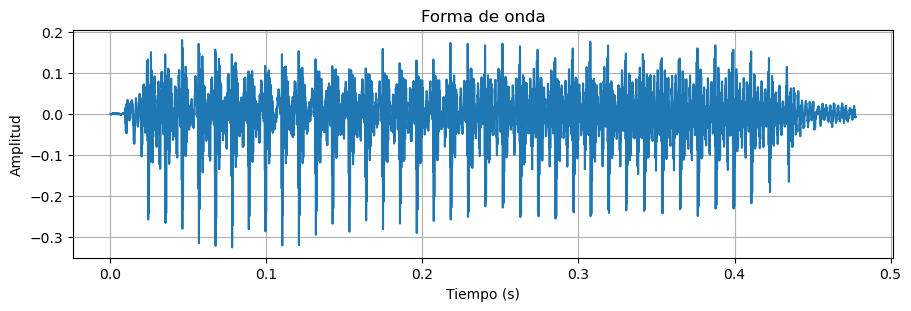

torch.Size([7642])


In [11]:
from cowaver.utils import cargar_audio

audio_path = kalulu_phonemes_path / "e-e.mp3"
waveform = cargar_audio(audio_path)
plot_waveform(waveform)
print(waveform.shape)

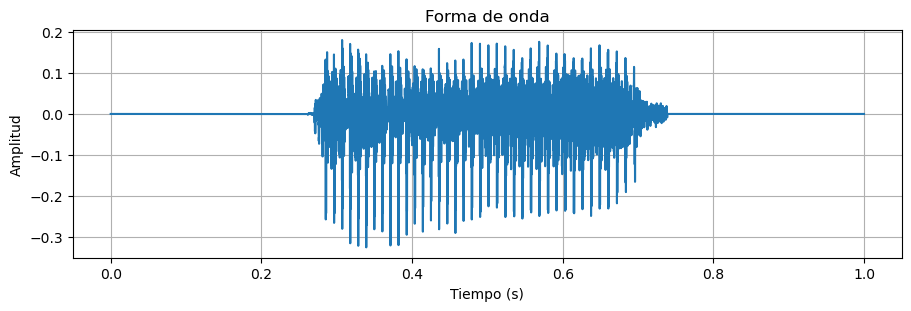

Audio(value=b'RIFF\xb0w\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

In [12]:
from cowaver.transforms import RandomAlign

transform = RandomAlign()
transformed_waveform = transform(waveform)
plot_waveform(transformed_waveform)
display(audio_widget(waveform))
display(audio_widget(transformed_waveform))

Audio(value=b'RIFF\xb0w\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

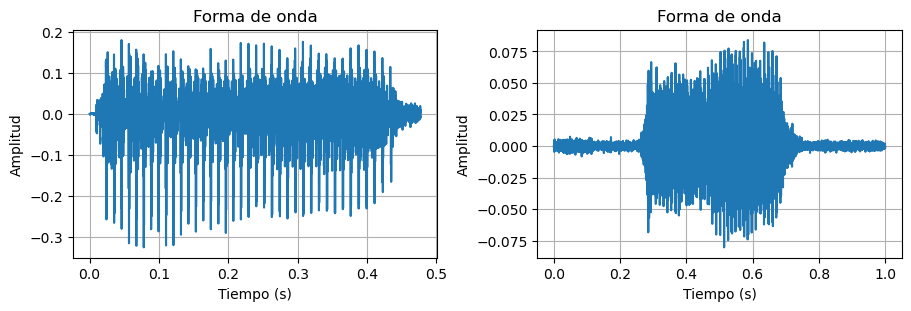

In [13]:
from torchvision.transforms import Compose
from cowaver.transforms import (
    RandomAlign,
    RandomNoise,
    RandomPitch,
    RandomNotch,
    RandomLowpass,
    RandomHighpass,
    RandomBandpass
)

transform = Compose([
    RandomAlign(0.5),
    RandomNoise(),
    RandomPitch(),
    RandomNotch(),
    RandomLowpass(),
    RandomHighpass(),
    RandomBandpass()
])
transformed_waveform = transform(waveform)
fig = plt.figure(figsize=(9, 3), layout="constrained")
axes = fig.subplot_mosaic([["x", "x_transformed"]])
plot_waveform(waveform, axes["x"])
plot_waveform(transformed_waveform, axes["x_transformed"])
display(audio_widget(waveform))
display(audio_widget(transformed_waveform))

Audio(value=b'RIFF\xb0w\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

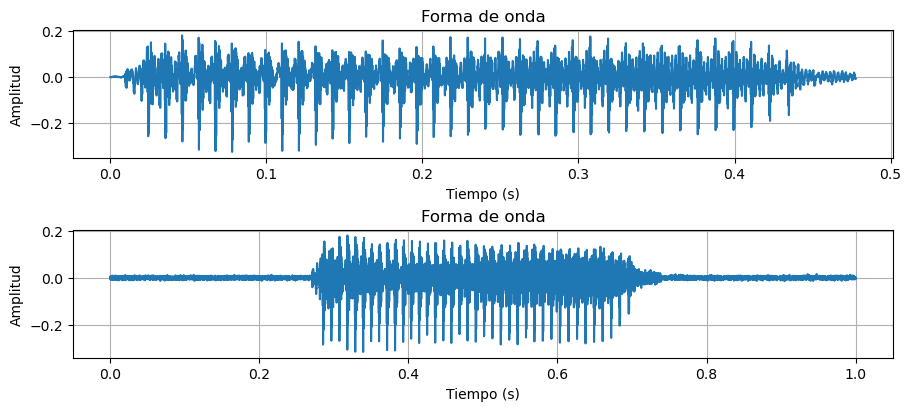

In [14]:
from torchvision.transforms import Compose
from cowaver.transforms import RandomAlign, RandomScene

transform = Compose([RandomAlign(), RandomScene()])

transformed_waveform = transform(waveform)
fig = plt.figure(figsize=(9, 4), layout="constrained")
axes = fig.subplot_mosaic([["x"], ["x_transformed"]])
plot_waveform(waveform, axes["x"])
plot_waveform(transformed_waveform, axes["x_transformed"])
display(audio_widget(waveform))
display(audio_widget(transformed_waveform))